# Neural Networks and Deep Learning (ECS7026P)
## Part 1: CIFAR-10 Image Classification




## Imports and Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import json

# Detect device — will use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Section 1.1 Dataset and DataLoaders

The CIFAR-10 dataset contains 60,000 small (3 × 32 × 32) colour images across 10 classes.
- Training set: 50,000 images
- Test set: 10,000 images
- Classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

We create a DataLoader for the training set and a DataLoader for the test set,
both generating batches of examples as required by the spec.

In [2]:
BATCH_SIZE = 64

# Standard CIFAR-10 per-channel mean and std for normalisation
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

# Base transforms — ToTensor and normalisation only, no augmentation
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

# Download and load CIFAR-10
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform
)

# Create DataLoaders — generates batches for training and testing
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

CLASSES = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f'Training samples : {len(train_dataset)}')
print(f'Test samples     : {len(test_dataset)}')
print(f'Training batches : {len(train_loader)}')
print(f'Test batches     : {len(test_loader)}')

Training samples : 50000
Test samples     : 10000
Training batches : 782
Test batches     : 157


### 1.1.1 Dataset Visualisation
Quick check to confirm the DataLoader is working and images look correct.

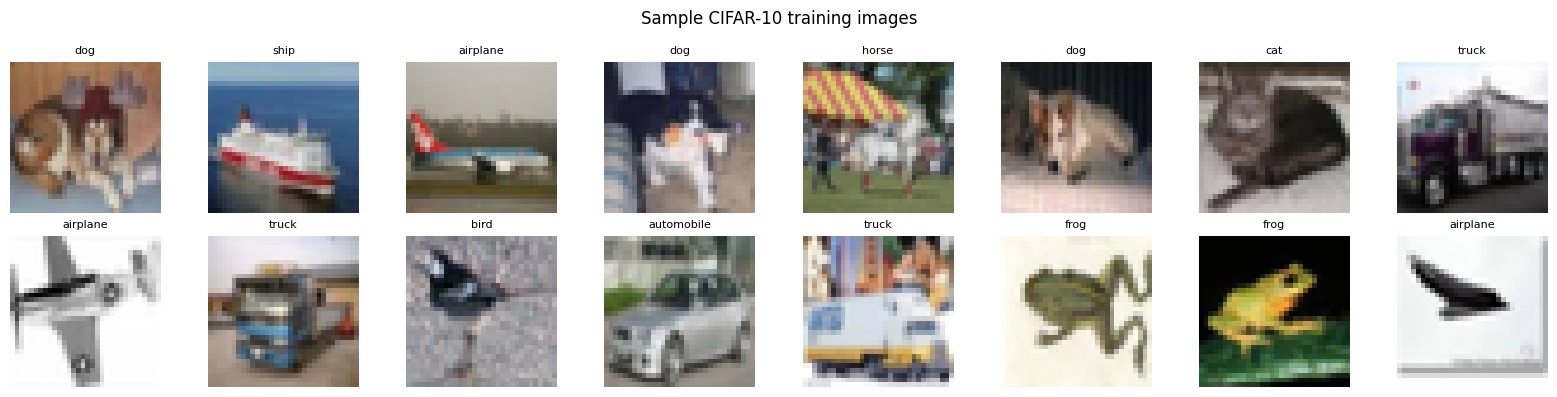

Image batch shape : torch.Size([64, 3, 32, 32])
Label batch shape : torch.Size([64])


In [3]:
def denormalise(tensor, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    """Reverse normalisation for display purposes."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std  = torch.tensor(std).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    img = denormalise(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASSES[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 training images', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Image batch shape : {images.shape}')   # Expected: torch.Size([64, 3, 32, 32])
print(f'Label batch shape : {labels.shape}')   # Expected: torch.Size([64])

## Section 1.2 Basic Architecture

The architecture is composed of:
- A sequence of **K Intermediate Blocks** (B1, B2, ..., BK)
- Followed by one **Output Block** (O)

### Section 1.2.1: Intermediate Block

Each intermediate block receives image **x** and outputs image **x'** using the formula: 
x' = a1*C1(x) + a2*C2(x) + ... + aL*CL(x)

Where:
- C1...CL are **L independent parallel conv layers**, all receiving the same input x
- **a** is a weighting vector computed by a FC layer that reads the channel-wise average of x
- The FC layer has exactly L output units (one weight per conv layer)
- All conv layers output images of the same shape

In [4]:
class IntermediateBlock(nn.Module):
    """
    Intermediate block as described in Section 1.2.1 of the assignment.

    Receives image x of shape (B, in_channels, H, W) and outputs
    image x' of shape (B, out_channels, H, W) as a learned weighted
    sum of L independent parallel convolutional outputs:

        x' = a1*C1(x) + a2*C2(x) + ... + aL*CL(x)

    Args:
        in_channels     : number of input channels (c)
        out_channels    : number of output channels per conv layer
        num_conv_layers : number of independent parallel conv layers (L)
        kernel_size     : conv kernel size (default 3)
    """

    def __init__(self, in_channels, out_channels, num_conv_layers, kernel_size=3):
        super().__init__()

        self.num_conv_layers = num_conv_layers

        # L independent parallel conv layers.
        # padding = kernel_size // 2 preserves spatial dimensions H and W.
        # All L layers must output images of the same shape — padding ensures this.
        self.conv_layers = nn.ModuleList([
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                padding=kernel_size // 2
            )
            for _ in range(num_conv_layers)
        ])

        # Fully connected layer:
        #   input  -> c-dimensional channel average of x  (in_channels)
        #   output -> L weights, one per conv layer       (num_conv_layers)
        self.fc = nn.Linear(in_channels, num_conv_layers)

    def forward(self, x):
        """
        Args:
            x : tensor of shape (B, C, H, W)
        Returns:
            x_prime : tensor of shape (B, out_channels, H, W)
        """
        # Step 1: compute channel-wise spatial average -> m of shape (B, C)
        # This is the 'average value of each channel' described in the spec
        m = x.mean(dim=[2, 3])

        # Step 2: FC layer -> weighting vector a of shape (B, L)
        a = self.fc(m)

        # Step 3: run all L conv layers on the same input x
        # NOTE: each conv receives x directly — not the output of another conv
        conv_outputs = [F.relu(conv(x)) for conv in self.conv_layers]
        # Each output: (B, out_channels, H, W)

        # Step 4: stack all conv outputs -> (B, L, out_channels, H, W)
        stack = torch.stack(conv_outputs, dim=1)

        # Step 5: reshape a for broadcasting -> (B, L, 1, 1, 1)
        a = a.view(a.size(0), self.num_conv_layers, 1, 1, 1)

        # Step 6: weighted sum over L dimension -> (B, out_channels, H, W)
        # This implements: x' = a1*C1(x) + a2*C2(x) + ... + aL*CL(x)
        x_prime = (stack * a).sum(dim=1)

        return x_prime

### Section 1.2.2: Output Block

The output block receives the final image x from the last intermediate block
and outputs a logits vector **o** of size 10 (one per class).

- Computes the channel-wise average of x -> vector m
- Passes m through one or more FC layers -> logits o

In [5]:
class OutputBlock(nn.Module):
    """
    Output block as described in Section 1.2.2 of the assignment.

    Receives image x of shape (B, C, H, W), computes the channel-wise
    spatial average, then passes through FC layer(s) to produce
    a logits vector of shape (B, num_classes).

    Args:
        in_channels : number of input channels
        num_classes : number of output classes (10 for CIFAR-10)
        hidden_dim  : optional hidden layer size (None = single FC layer)
    """

    def __init__(self, in_channels, num_classes=10, hidden_dim=None):
        super().__init__()

        if hidden_dim is not None:
            # Two FC layers with ReLU between them (zero or more FC layers per spec)
            self.fc = nn.Sequential(
                nn.Linear(in_channels, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, num_classes)
            )
        else:
            # Single FC layer — simplest valid option per the spec
            self.fc = nn.Linear(in_channels, num_classes)

    def forward(self, x):
        """
        Args:
            x : tensor of shape (B, C, H, W)
        Returns:
            o : logits tensor of shape (B, num_classes)
        """
        # Channel-wise spatial average -> m of shape (B, C)
        m = x.mean(dim=[2, 3])
        # FC layer(s) -> logits of shape (B, num_classes)
        return self.fc(m)

### Section 1.2.3: Full Network (BasicNet)

Stacks K intermediate blocks followed by one output block.
The architecture is fully configurable via `block_configs`.

In [6]:
class BasicNet(nn.Module):
    """
    Full network as described in Section 1.2 of the assignment.
    K intermediate blocks followed by one output block.

    Args:
        block_configs : list of dicts, one per intermediate block.
                        Required keys: in_channels, out_channels, num_conv_layers
                        Optional keys: kernel_size (default 3)
        num_classes   : number of output classes (default 10)
        hidden_dim    : hidden layer size in output block (default None)
    """

    def __init__(self, block_configs, num_classes=10, hidden_dim=None):
        super().__init__()

        # Build K intermediate blocks
        self.blocks = nn.ModuleList([
            IntermediateBlock(
                in_channels=cfg['in_channels'],
                out_channels=cfg['out_channels'],
                num_conv_layers=cfg['num_conv_layers'],
                kernel_size=cfg.get('kernel_size', 3)
            )
            for cfg in block_configs
        ])

        # Output block reads from the last intermediate block's output channels
        final_channels = block_configs[-1]['out_channels']
        self.output_block = OutputBlock(final_channels, num_classes, hidden_dim)

    def forward(self, x):
        """
        Args:
            x : tensor of shape (B, 3, 32, 32)
        Returns:
            o : logits tensor of shape (B, 10)
        """
        # Pass through each intermediate block in sequence
        for block in self.blocks:
            x = block(x)
        # Final output block
        return self.output_block(x)

### 1.2.4: Model Instantiation and Sanity Check

In [7]:
# ── Baseline architecture config ───────────────────────────────────────────
# K=3 intermediate blocks with L=3, 3, 2 parallel conv layers respectively
# Channels: 3 -> 64 -> 128 -> 256
# hidden_dim=512 adds a hidden layer in the output block (allowed by spec)
block_configs = [
    {'in_channels': 3,   'out_channels': 64,  'num_conv_layers': 3, 'kernel_size': 3},
    {'in_channels': 64,  'out_channels': 128, 'num_conv_layers': 3, 'kernel_size': 3},
    {'in_channels': 128, 'out_channels': 256, 'num_conv_layers': 2, 'kernel_size': 3},
]
HIDDEN_DIM = 512
# ───────────────────────────────────────────────────────────────────────────

# Instantiate model and move to device
model = BasicNet(block_configs, num_classes=10, hidden_dim=HIDDEN_DIM).to(device)

# Sanity check — verify correct output shape before training
dummy_input  = torch.randn(4, 3, 32, 32).to(device)
dummy_output = model(dummy_input)

print(f'Input shape  : {dummy_input.shape}')    # Expected: torch.Size([4, 3, 32, 32])
print(f'Output shape : {dummy_output.shape}')   # Expected: torch.Size([4, 10])

assert dummy_output.shape == (4, 10), 'Shape mismatch — check the architecture'
print('Sanity check passed ✓')

# Total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')

Input shape  : torch.Size([4, 3, 32, 32])
Output shape : torch.Size([4, 10])
Sanity check passed ✓
Total trainable parameters: 954,459


## Section 1.3: Training and Testing

We train the basic architecture using cross-entropy loss and evaluate
its accuracy on the test dataset after each epoch.

The network receives a b × 3 × 32 × 32 input tensor and outputs a b × 10 logits matrix.

### 1.3.1: Evaluation Function

In [8]:
def evaluate(model, loader, device):
    """
    Compute classification accuracy over a full DataLoader.
    No weight updates are performed.

    Args:
        model  : nn.Module
        loader : DataLoader (train or test)
        device : torch device

    Returns:
        accuracy : float in [0, 1]
    """
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs   = model(images)          # forward pass, no grad
            predicted = outputs.argmax(dim=1)  # predicted class index
            correct  += predicted.eq(labels).sum().item()
            total    += labels.size(0)

    return correct / total

### 1.3.2 Training Function

In [9]:
def train(model, train_loader, test_loader, device,
          epochs=20, lr=1e-3, weight_decay=0.0):
    """
    Full training loop using cross-entropy loss as required by the spec.

    Records:
        - Loss for every training batch
        - Training accuracy after each epoch
        - Test accuracy after each epoch

    Args:
        model        : nn.Module to train
        train_loader : DataLoader for the training set
        test_loader  : DataLoader for the test set
        device       : torch device
        epochs       : number of training epochs
        lr           : learning rate
        weight_decay : L2 regularisation strength (default 0)

    Returns:
        batch_losses     : list of float, one loss value per training batch
        train_accuracies : list of float, one accuracy value per epoch
        test_accuracies  : list of float, one accuracy value per epoch
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )

    batch_losses     = []
    train_accuracies = []
    test_accuracies  = []

    for epoch in range(1, epochs + 1):
        model.train()
        correct, total = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)               # forward pass
            loss    = criterion(outputs, labels)  # cross-entropy loss
            loss.backward()                       # backpropagation
            optimizer.step()                      # update weights

            # Store batch loss
            batch_losses.append(loss.item())

            # Accumulate correct predictions for training accuracy
            predicted = outputs.argmax(dim=1)
            correct  += predicted.eq(labels).sum().item()
            total    += labels.size(0)

        # Compute epoch-level metrics
        train_acc = correct / total
        test_acc  = evaluate(model, test_loader, device)

        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)

        print(f'Epoch [{epoch:>3}/{epochs}]  '
              f'Train Acc: {train_acc:.4f}  '
              f'Test Acc: {test_acc:.4f}  '
              f'Last Batch Loss: {batch_losses[-1]:.4f}')

    return batch_losses, train_accuracies, test_accuracies

### 1.3.3: Run Training

In [ ]:
# ── Training hyperparameters ──────
EPOCHS        = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 0.0
BATCH_SIZE    = 64
# ───────────────────────────────────────────────────────────────────────────

# Fresh model instance before training
model = BasicNet(block_configs, num_classes=10, hidden_dim=HIDDEN_DIM).to(device)

# Run training
batch_losses, train_accuracies, test_accuracies = train(
    model, train_loader, test_loader, device,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print(f'\nBest test accuracy : {max(test_accuracies)*100:.2f}%')

Epoch [  1/30]  Train Acc: 0.2915  Test Acc: 0.3915  Last Batch Loss: 1.7041
Epoch [  2/30]  Train Acc: 0.4571  Test Acc: 0.5215  Last Batch Loss: 1.3396
Epoch [  3/30]  Train Acc: 0.5551  Test Acc: 0.5822  Last Batch Loss: 1.3326
Epoch [  4/30]  Train Acc: 0.6164  Test Acc: 0.6465  Last Batch Loss: 1.0973
Epoch [  5/30]  Train Acc: 0.6641  Test Acc: 0.6582  Last Batch Loss: 1.2308
Epoch [  6/30]  Train Acc: 0.6969  Test Acc: 0.6925  Last Batch Loss: 0.7923
Epoch [  7/30]  Train Acc: 0.7216  Test Acc: 0.7075  Last Batch Loss: 0.9270
Epoch [  8/30]  Train Acc: 0.7456  Test Acc: 0.7232  Last Batch Loss: 0.4959
Epoch [  9/30]  Train Acc: 0.7665  Test Acc: 0.7399  Last Batch Loss: 0.5231
Epoch [ 10/30]  Train Acc: 0.7875  Test Acc: 0.7481  Last Batch Loss: 0.6570
Epoch [ 11/30]  Train Acc: 0.8030  Test Acc: 0.7529  Last Batch Loss: 0.3581
Epoch [ 12/30]  Train Acc: 0.8200  Test Acc: 0.7697  Last Batch Loss: 0.4004
Epoch [ 13/30]  Train Acc: 0.8357  Test Acc: 0.7561  Last Batch Loss: 0.4067

### 1.3.4: Plot: Training Loss per Batch
Required by the assignment spec.

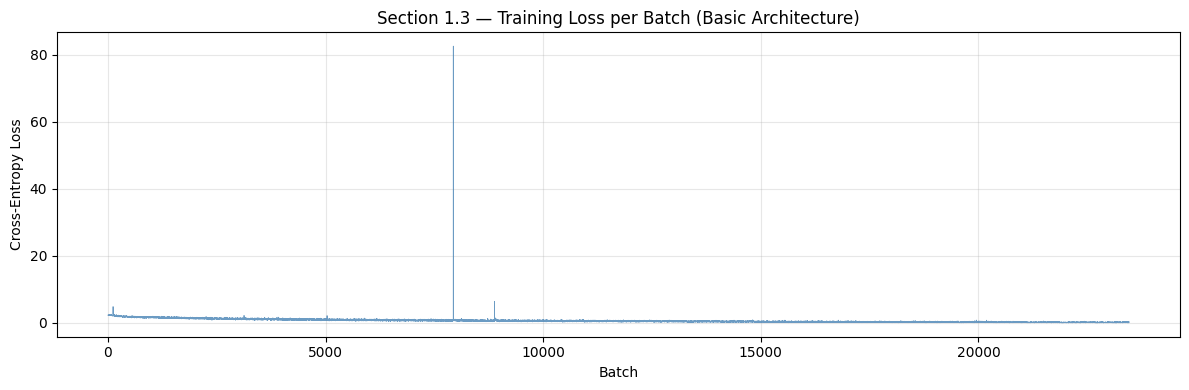

Saved: basic_batch_loss.png


In [11]:
plt.figure(figsize=(12, 4))
plt.plot(batch_losses, linewidth=0.6, alpha=0.8, color='steelblue')
plt.xlabel('Batch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Section 1.3 — Training Loss per Batch (Basic Architecture)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('basic_batch_loss.png', dpi=150)
plt.show()
print('Saved: basic_batch_loss.png')

### 1.3.5: Plot: Training and Test Accuracy per Epoch
Required by the assignment spec.

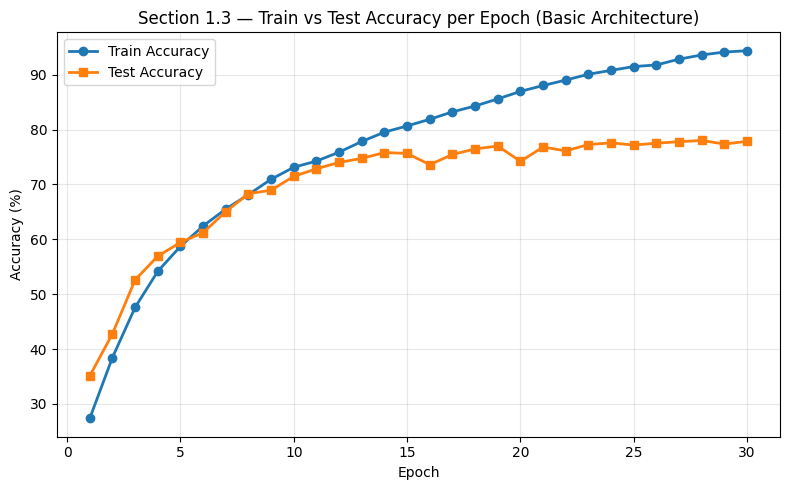

Final train accuracy : 94.36%
Final test accuracy  : 77.85%
Best  test accuracy  : 78.01%
Saved: basic_accuracy.png


In [12]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, [a * 100 for a in train_accuracies],
         label='Train Accuracy', marker='o', linewidth=2)
plt.plot(epochs_range, [a * 100 for a in test_accuracies],
         label='Test Accuracy',  marker='s', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Section 1.3 — Train vs Test Accuracy per Epoch (Basic Architecture)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('basic_accuracy.png', dpi=150)
plt.show()

print(f'Final train accuracy : {train_accuracies[-1]*100:.2f}%')
print(f'Final test accuracy  : {test_accuracies[-1]*100:.2f}%')
print(f'Best  test accuracy  : {max(test_accuracies)*100:.2f}%')
print('Saved: basic_accuracy.png')

### 1.3.6: Save Basic Model and Statistics

In [13]:
# Save basic model weights — done AFTER training is complete
torch.save(model.state_dict(), 'basic_model.pth')
print('Basic model weights saved to basic_model.pth')

# Save training statistics as JSON
stats = {
    'batch_losses'     : batch_losses,
    'train_accuracies' : train_accuracies,
    'test_accuracies'  : test_accuracies,
    'best_test_acc'    : max(test_accuracies)
}
with open('basic_training_stats.json', 'w') as f:
    json.dump(stats, f)
print('Training statistics saved to basic_training_stats.json')

Basic model weights saved to basic_model.pth
Training statistics saved to basic_training_stats.json


## Section 1.4: Improving the Results

Improved train batches: 391
Improved test  batches: 79
Improved model sanity check passed ✓
Total trainable parameters: 5,294,561
Epoch [  1/120]  Train: 0.3765  Test: 0.5798  LR: 0.09998  Best: 0.5798
Epoch [  2/120]  Train: 0.6050  Test: 0.5973  LR: 0.09993  Best: 0.5973
Epoch [  3/120]  Train: 0.6707  Test: 0.6585  LR: 0.09985  Best: 0.6585
Epoch [  4/120]  Train: 0.7080  Test: 0.6278  LR: 0.09973  Best: 0.6585
Epoch [  5/120]  Train: 0.7298  Test: 0.7222  LR: 0.09957  Best: 0.7222
Epoch [  6/120]  Train: 0.7489  Test: 0.7274  LR: 0.09938  Best: 0.7274
Epoch [  7/120]  Train: 0.7592  Test: 0.7595  LR: 0.09916  Best: 0.7595
Epoch [  8/120]  Train: 0.7658  Test: 0.7440  LR: 0.09891  Best: 0.7595
Epoch [  9/120]  Train: 0.7747  Test: 0.7744  LR: 0.09862  Best: 0.7744
Epoch [ 10/120]  Train: 0.7821  Test: 0.6998  LR: 0.09830  Best: 0.7744
Epoch [ 11/120]  Train: 0.7867  Test: 0.7861  LR: 0.09794  Best: 0.7861
Epoch [ 12/120]  Train: 0.7885  Test: 0.7906  LR: 0.09755  Best: 0.7906
Epoch 

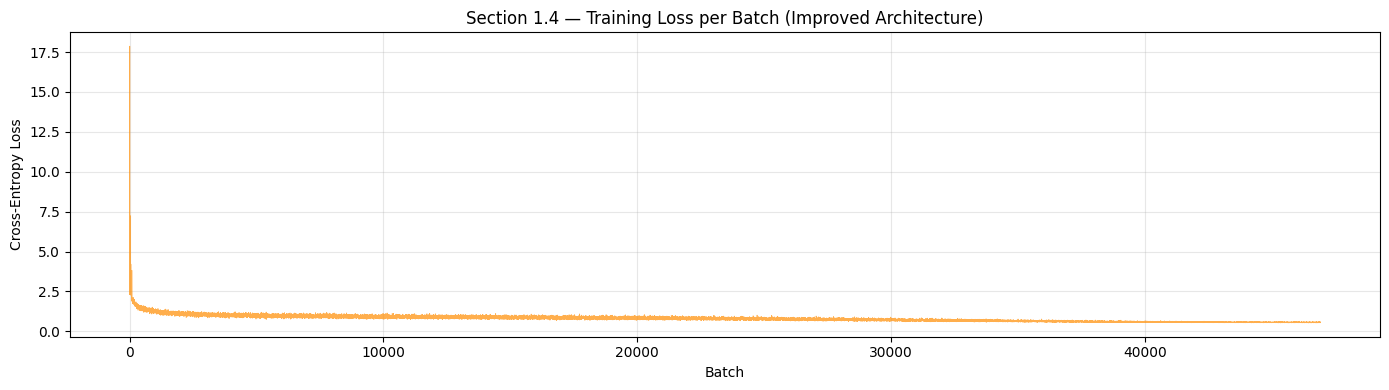

Saved: improved_batch_loss.png


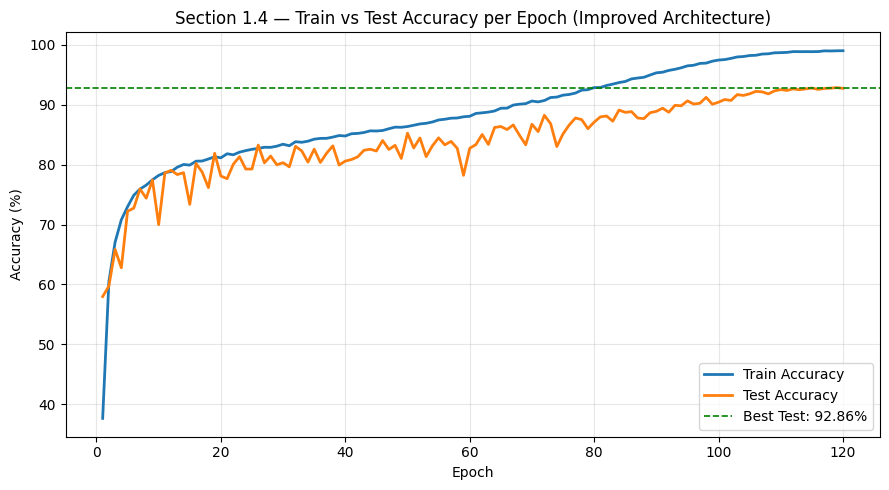

Final train accuracy : 99.03%
Final test  accuracy : 92.75%
Best  test  accuracy : 92.86%
Saved: improved_accuracy.png
Training statistics saved to improved_training_stats.json


In [14]:
# ______________________________________________________________________________
# Section 1.4 — Improved Architecture and Training
# ______________________________________________________________________________

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import json

# 1. Augmented DataLoaders ──────────────────────────────────────────────────
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

improved_train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2)),
])

improved_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

import torchvision
IMPROVED_BATCH_SIZE = 128

improved_train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=improved_train_transform
)
improved_test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=False, transform=improved_test_transform
)

improved_train_loader = torch.utils.data.DataLoader(
    improved_train_dataset, batch_size=IMPROVED_BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True
)
improved_test_loader = torch.utils.data.DataLoader(
    improved_test_dataset, batch_size=IMPROVED_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

print(f'Improved train batches: {len(improved_train_loader)}')
print(f'Improved test  batches: {len(improved_test_loader)}')


# 2. Improved Intermediate Block ────────────────────────────────────────────
class ImprovedIntermediateBlock(nn.Module):
    """
    Same spec-compliant architecture as IntermediateBlock:
      x' = a1*C1(x) + a2*C2(x) + ... + aL*CL(x)
    where a = FC(channel_mean(x)).

    Improvements over the basic block:
      - Each conv is followed by BatchNorm + ReLU (better gradient flow)
      - Optional downsampling via MaxPool between blocks (controlled externally)
    """

    def __init__(self, in_channels, out_channels, num_conv_layers, kernel_size=3):
        super().__init__()
        self.num_conv_layers = num_conv_layers
        padding = kernel_size // 2

        # L independent parallel branches: Conv -> BN -> ReLU
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            )
            for _ in range(num_conv_layers)
        ])

        # FC: channel mean of input -> L scalar weights (same as basic block)
        self.fc = nn.Linear(in_channels, num_conv_layers)

    def forward(self, x):
        # Step 1: channel-wise spatial average -> (B, C)
        m = x.mean(dim=[2, 3])
        # Step 2: FC -> weighting vector a of shape (B, L)
        a = self.fc(m)
        # Step 3: run all L branches on x
        branch_outputs = [branch(x) for branch in self.branches]   # each (B, out_channels, H, W)
        # Step 4: stack -> (B, L, out_channels, H, W)
        stack = torch.stack(branch_outputs, dim=1)
        # Step 5: reshape a for broadcasting -> (B, L, 1, 1, 1)
        a = a.view(a.size(0), self.num_conv_layers, 1, 1, 1)
        # Step 6: weighted sum -> (B, out_channels, H, W)
        return (stack * a).sum(dim=1)


# 3. Improved Full Network ──────────────────────────────────────────────────
class ImprovedNet(nn.Module):
    """
    K ImprovedIntermediateBlocks followed by an OutputBlock.
    MaxPool2d layers are inserted *between* blocks (mild architectural change
    explicitly permitted by the assignment spec) to build a spatial hierarchy.
    """

    def __init__(self, block_configs, pool_after=None, num_classes=10, hidden_dim=512):
        """
        Args:
            block_configs : list of dicts with keys:
                              in_channels, out_channels, num_conv_layers, kernel_size
            pool_after    : set of block indices (0-based) after which to apply MaxPool2d(2,2)
            num_classes   : 10 for CIFAR-10
            hidden_dim    : hidden size in output block
        """
        super().__init__()
        if pool_after is None:
            pool_after = set()

        self.blocks = nn.ModuleList()
        self.pool_after = pool_after

        for cfg in block_configs:
            self.blocks.append(
                ImprovedIntermediateBlock(
                    in_channels=cfg['in_channels'],
                    out_channels=cfg['out_channels'],
                    num_conv_layers=cfg['num_conv_layers'],
                    kernel_size=cfg.get('kernel_size', 3),
                )
            )

        final_channels = block_configs[-1]['out_channels']
        # Output block: channel mean -> FC(hidden_dim) -> ReLU -> Dropout -> FC(num_classes)
        self.output_block = nn.Sequential(
            nn.Linear(final_channels, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        for i, block in enumerate(self.blocks):
            x = block(x)
            if i in self.pool_after:
                x = F.max_pool2d(x, kernel_size=2, stride=2)
        # Channel-wise spatial average, then output FC layers
        m = x.mean(dim=[2, 3])          # (B, C)
        return self.output_block(m)


# 4. Instantiate the improved model ─────────────────────────────────────────
improved_block_configs = [
    # Block 0: 3  -> 64,  L=3  (32×32 input) → pool after → 16×16
    {'in_channels': 3,   'out_channels': 64,  'num_conv_layers': 3, 'kernel_size': 3},
    # Block 1: 64 -> 128, L=4  (16×16) → pool after → 8×8
    {'in_channels': 64,  'out_channels': 128, 'num_conv_layers': 4, 'kernel_size': 3},
    # Block 2: 128 -> 256, L=4 (8×8) → pool after → 4×4
    {'in_channels': 128, 'out_channels': 256, 'num_conv_layers': 4, 'kernel_size': 3},
    # Block 3: 256 -> 512, L=3 (4×4) — no pool; spatial avg in output block
    {'in_channels': 256, 'out_channels': 512, 'num_conv_layers': 3, 'kernel_size': 3},
]

improved_model = ImprovedNet(
    block_configs=improved_block_configs,
    pool_after={0, 1, 2},   # MaxPool after blocks 0, 1, 2
    num_classes=10,
    hidden_dim=512,
).to(device)

# Sanity check
dummy = torch.randn(4, 3, 32, 32).to(device)
assert improved_model(dummy).shape == (4, 10), 'Shape mismatch!'
print('Improved model sanity check passed ✓')

total_params = sum(p.numel() for p in improved_model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')


# Improved training loop ─────────────────────────────────────────────────
def train_improved(model, train_loader, test_loader, device,
                   epochs=120, lr=0.1, weight_decay=5e-4):
    """
    Improved training loop:
      - SGD + Nesterov momentum
      - CosineAnnealingLR (smooth decay, no manual step tuning)
      - Label smoothing (reduces overconfidence / overfitting)
      - Saves the best model checkpoint based on test accuracy

    Returns:
        batch_losses      : loss per training batch
        train_accuracies  : train accuracy per epoch
        test_accuracies   : test accuracy per epoch
        best_test_acc     : highest test accuracy seen
    """
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.SGD(
        model.parameters(), lr=lr, momentum=0.9,
        weight_decay=weight_decay, nesterov=True
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    batch_losses     = []
    train_accuracies = []
    test_accuracies  = []
    best_test_acc    = 0.0

    for epoch in range(1, epochs + 1):
        model.train()
        correct, total = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            # Gradient clipping — prevents instability in early epochs
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            batch_losses.append(loss.item())
            predicted = outputs.argmax(dim=1)
            correct  += predicted.eq(labels).sum().item()
            total    += labels.size(0)

        scheduler.step()

        train_acc = correct / total
        test_acc  = evaluate(model, test_loader, device)   # reuse evaluate() from Section 1.3

        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)

        # Save best model checkpoint
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save(model.state_dict(), 'improved_model_best.pth')

        current_lr = scheduler.get_last_lr()[0]
        print(f'Epoch [{epoch:>3}/{epochs}]  '
              f'Train: {train_acc:.4f}  Test: {test_acc:.4f}  '
              f'LR: {current_lr:.5f}  Best: {best_test_acc:.4f}')

    return batch_losses, train_accuracies, test_accuracies, best_test_acc


# 6. Run improved training ──────────────────────────────────────────────────
IMPROVED_EPOCHS = 120

(improved_batch_losses,
 improved_train_accuracies,
 improved_test_accuracies,
 improved_best_test_acc) = train_improved(
    improved_model, improved_train_loader, improved_test_loader, device,
    epochs=IMPROVED_EPOCHS, lr=0.1, weight_decay=5e-4
)

print(f'\nBest test accuracy (improved): {improved_best_test_acc * 100:.2f}%')


# 7. Load best checkpoint and verify ───────────────────────────────────────
improved_model.load_state_dict(torch.load('improved_model_best.pth', map_location=device))
final_test_acc = evaluate(improved_model, improved_test_loader, device)
print(f'Test accuracy with best checkpoint: {final_test_acc * 100:.2f}%')
torch.save(improved_model.state_dict(), 'improved_model.pth')
print('Saved: improved_model.pth')


# 8. Plot: Batch loss ───────────────────────────────────────────────────────
plt.figure(figsize=(14, 4))
plt.plot(improved_batch_losses, linewidth=0.5, alpha=0.7, color='darkorange')
plt.xlabel('Batch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Section 1.4 — Training Loss per Batch (Improved Architecture)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('improved_batch_loss.png', dpi=150)
plt.show()
print('Saved: improved_batch_loss.png')


# 9. Plot: Train vs Test accuracy ─────────────────────────────────────────
epochs_range = range(1, IMPROVED_EPOCHS + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_range, [a * 100 for a in improved_train_accuracies],
         label='Train Accuracy', linewidth=2)
plt.plot(epochs_range, [a * 100 for a in improved_test_accuracies],
         label='Test Accuracy', linewidth=2)
plt.axhline(improved_best_test_acc * 100, color='green', linestyle='--',
            linewidth=1.2, label=f'Best Test: {improved_best_test_acc*100:.2f}%')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Section 1.4 — Train vs Test Accuracy per Epoch (Improved Architecture)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('improved_accuracy.png', dpi=150)
plt.show()

print(f'Final train accuracy : {improved_train_accuracies[-1]*100:.2f}%')
print(f'Final test  accuracy : {improved_test_accuracies[-1]*100:.2f}%')
print(f'Best  test  accuracy : {improved_best_test_acc*100:.2f}%')
print('Saved: improved_accuracy.png')


# 10. Save statistics ──────────────────────────────────────────────────────
improved_stats = {
    'batch_losses'     : improved_batch_losses,
    'train_accuracies' : improved_train_accuracies,
    'test_accuracies'  : improved_test_accuracies,
    'best_test_acc'    : improved_best_test_acc,
}
with open('improved_training_stats.json', 'w') as f:
    json.dump(improved_stats, f)
print('Training statistics saved to improved_training_stats.json')
